## 1. Import Libraries

In [37]:
# Core libraries
import numpy as np
import pandas as pd
import cv2
import os
import json
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew

# Machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Multiprocessing
from multiprocessing import Pool, cpu_count
import functools

warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Available CPU cores: {cpu_count()}")

Libraries imported successfully
NumPy version: 2.2.6
OpenCV version: 4.12.0
Available CPU cores: 12


## 2. Configuration

In [38]:
# Dataset paths
DATASET_ROOT = "dataset_20class"
TRAIN_DIR = f"{DATASET_ROOT}/train"
VAL_DIR = f"{DATASET_ROOT}/val"
TEST_DIR = f"{DATASET_ROOT}/test"

# Feature extraction parameters
IMG_SIZE = (256, 256)
LBP_RADIUS = 3
LBP_N_POINTS = 24
GLCM_DISTANCES = [1, 2]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_LEVELS = 32

# KNN parameters
KNN_N_NEIGHBORS = 5
KNN_WEIGHTS = 'distance'
KNN_METRIC = 'euclidean'

# PCA parameters
PCA_VARIANCE = 0.95

# Training parameters
RANDOM_STATE = 42
CV_FOLDS = 5

# Feature caching
ENABLE_FEATURE_CACHE = True
FORCE_REEXTRACT = False
CACHE_DIR = "features_cache"

# Multiprocessing
USE_MULTIPROCESSING = True
N_WORKERS = None

# Output
MODEL_NAME = "Batik_KNN_19Class.pkl"
CONFIG_NAME = "batik_config_knn_19class.json"

# Visualization
N_SAMPLE_IMAGES = 6

print("Configuration loaded")
print("="*60)
print("DATASET CONFIGURATION")
print("="*60)
print(f"Dataset: {DATASET_ROOT}")
print(f"  - 19 visually distinct classes")
print(f"  - Train/Val/Test splits included")
print(f"Image size: {IMG_SIZE}")
print(f"Feature caching: {'Enabled' if ENABLE_FEATURE_CACHE else 'Disabled'}")
print(f"Multiprocessing: {'Enabled' if USE_MULTIPROCESSING else 'Disabled'}")
print("\nKNN Configuration:")
print(f"  n_neighbors={KNN_N_NEIGHBORS}, weights={KNN_WEIGHTS}, metric={KNN_METRIC}")
print(f"\nOutput model: {MODEL_NAME}")
print(f"PCA variance: {PCA_VARIANCE*100}%")
print("="*60)

Configuration loaded
DATASET CONFIGURATION
Dataset: dataset_20class
  - 19 visually distinct classes
  - Train/Val/Test splits included
Image size: (256, 256)
Feature caching: Enabled
Multiprocessing: Enabled

KNN Configuration:
  n_neighbors=5, weights=distance, metric=euclidean

Output model: Batik_KNN_19Class.pkl
PCA variance: 95.0%


## 3. Feature Extraction Functions

### 3.1 Image Preprocessing

In [39]:
def preprocess_image(image, img_size):
    """
    Preprocess image: resize and convert color spaces

    Returns:
        resized_bgr: Resized BGR image
        hsv_img: HSV color space
        gray_img: Grayscale image
    """
    if image is None:
        return None, None, None

    # Resize
    resized_bgr = cv2.resize(image, img_size)

    # Convert to HSV
    hsv_img = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2HSV)

    # Convert to grayscale
    gray_img = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2GRAY)

    return resized_bgr, hsv_img, gray_img

print("Preprocessing function defined")

Preprocessing function defined


### 3.2 HSV Color Moments

In [40]:
def extract_hsv_features(hsv_img):
    """
    Extract HSV color moments (mean, std, skewness) for each channel

    Returns: 9 features (3 moments x 3 channels)
    """
    features = []

    for i in range(3):
        channel = hsv_img[:, :, i].flatten()

        mean_val = np.mean(channel)
        std_val = np.std(channel)
        skew_val = skew(channel)

        features.extend([mean_val, std_val, skew_val])

    return np.array(features)

print("HSV feature extraction function defined")

HSV feature extraction function defined


### 3.3 GLCM Texture Features

In [41]:
def extract_glcm_features(gray_img, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    """
    Extract GLCM texture features with quantization to 32 levels

    Improvements:
    - Quantize grayscale to 32 levels for stability
    - Use multiple distances for better texture capture
    - Handle correlation NaN values gracefully
    - Average across all distances and angles for robustness

    Returns: 6 features (contrast, dissimilarity, homogeneity, energy, correlation, ASM)
    """
    # Quantize to 32 levels for stability
    levels = 32
    quantized = (gray_img // (256 // levels)).astype(np.uint8)

    # Compute GLCM
    glcm = graycomatrix(
        quantized,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    # Extract properties
    properties = ['contrast', 'dissimilarity', 'homogeneity',
                  'energy', 'correlation', 'ASM']

    features = []
    for prop in properties:
        values = graycoprops(glcm, prop)
        avg_value = np.mean(values)

        # Handle NaN values
        if np.isnan(avg_value) or np.isinf(avg_value):
            avg_value = 0.0

        features.append(avg_value)

    return np.array(features)

print("GLCM feature extraction function defined")

GLCM feature extraction function defined


### 3.4 LBP Histogram Features

In [42]:
def extract_lbp_features(gray_img, radius=3, n_points=24):
    """
    Extract Local Binary Pattern (LBP) histogram features

    Returns: 26 features (histogram bins for uniform LBP)
    """
    # Compute LBP
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')

    # Compute histogram
    n_bins = n_points + 2
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return hist

print("LBP feature extraction function defined")

LBP feature extraction function defined


### 3.5 Combined Feature Extraction

In [43]:
def extract_features_single(img_path, img_size, lbp_radius, lbp_n_points, glcm_distances, glcm_angles):
    """
    Extract combined features (HSV + GLCM + LBP) from a single image

    Returns: 41 features (9 HSV + 6 GLCM + 26 LBP)
    """
    try:
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            return None

        # Preprocess
        resized_bgr, hsv_img, gray_img = preprocess_image(img, img_size)

        # Extract features
        hsv_features = extract_hsv_features(hsv_img)
        glcm_features = extract_glcm_features(gray_img, glcm_distances, glcm_angles)
        lbp_features = extract_lbp_features(gray_img, lbp_radius, lbp_n_points)

        # Combine all features
        combined = np.concatenate([hsv_features, glcm_features, lbp_features])

        return combined

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

print("Combined feature extraction function defined")

Combined feature extraction function defined


### 3.6 Batch Feature Extraction with Caching

In [44]:
def load_image_paths(data_dir):
    """
    Load all image paths and labels from directory

    Returns: List of (image_path, label) tuples
    """
    paths_labels = []

    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(class_dir, img_name)
                paths_labels.append((img_path, class_name))

    return paths_labels

def extract_or_load_features(paths_labels, cache_file, dataset_name):
    """
    Extract features or load from cache if available
    """
    # Check cache
    if ENABLE_FEATURE_CACHE and not FORCE_REEXTRACT and os.path.exists(cache_file):
        print(f"Loading cached features from {cache_file}...")
        cached_data = np.load(cache_file, allow_pickle=True).item()
        X = cached_data['features']
        y = cached_data['labels']
        failed = cached_data.get('failed', [])
        print(f"Loaded {len(X)} samples from cache")
        return X, y, failed

    # Extract features
    print(f"Extracting features from {dataset_name}...")
    print(f"Total images: {len(paths_labels)}")

    X_list = []
    y_list = []
    failed = []

    if USE_MULTIPROCESSING and N_WORKERS != 1:
        n_workers = N_WORKERS if N_WORKERS else cpu_count()
        print(f"Using {n_workers} parallel workers...")

        extract_fn = functools.partial(
            extract_features_single,
            img_size=IMG_SIZE,
            lbp_radius=LBP_RADIUS,
            lbp_n_points=LBP_N_POINTS,
            glcm_distances=GLCM_DISTANCES,
            glcm_angles=GLCM_ANGLES
        )

        with Pool(n_workers) as pool:
            results = list(tqdm(
                pool.imap(extract_fn, [path for path, _ in paths_labels]),
                total=len(paths_labels),
                desc="Extracting"
            ))

        for (path, label), features in zip(paths_labels, results):
            if features is not None:
                X_list.append(features)
                y_list.append(label)
            else:
                failed.append(path)
    else:
        print("Using single thread...")
        for path, label in tqdm(paths_labels, desc="Extracting"):
            features = extract_features_single(
                path, IMG_SIZE, LBP_RADIUS, LBP_N_POINTS,
                GLCM_DISTANCES, GLCM_ANGLES
            )

            if features is not None:
                X_list.append(features)
                y_list.append(label)
            else:
                failed.append(path)

    X = np.array(X_list)
    y = np.array(y_list)

    print(f"Extraction complete: {len(X)} samples, {len(failed)} failed")

    # Save cache
    if ENABLE_FEATURE_CACHE:
        os.makedirs(CACHE_DIR, exist_ok=True)
        np.save(cache_file, {'features': X, 'labels': y, 'failed': failed})
        print(f"Features cached to {cache_file}")

    return X, y, failed

print("Batch feature extraction functions defined")

Batch feature extraction functions defined


## 4. Load Dataset and Extract Features

### 4.1 Load Image Paths

In [45]:
# Load training and test image paths
print("Loading training set...")
train_paths_labels = load_image_paths(TRAIN_DIR)
print(f"Found {len(train_paths_labels)} training images")

print("\nLoading test set...")
test_paths_labels = load_image_paths(TEST_DIR)
print(f"Found {len(test_paths_labels)} test images")

# Combine for statistics
all_paths_labels = train_paths_labels + test_paths_labels

if len(all_paths_labels) == 0:
    print("\nWARNING: No images found in dataset directories!")
    print("Please check the dataset paths in configuration.")
else:
    # Get unique classes
    unique_classes = sorted(set([label for _, label in all_paths_labels]))
    print(f"\nTotal images: {len(all_paths_labels)}")
    print(f"Number of classes: {len(unique_classes)}")

    print(f"\nDataset split:")
    print(f"  Training: {len(train_paths_labels)} images ({len(train_paths_labels)/len(all_paths_labels)*100:.1f}%)")
    print(f"  Test: {len(test_paths_labels)} images ({len(test_paths_labels)/len(all_paths_labels)*100:.1f}%)")

Loading training set...
Found 13337 training images

Loading test set...
Found 2868 test images

Total images: 16205
Number of classes: 19

Dataset split:
  Training: 13337 images (82.3%)
  Test: 2868 images (17.7%)


### 4.2 Extract Training Features

In [46]:
# Extract features from training set
train_cache_file = os.path.join(CACHE_DIR, "train_features_knn_19class.npy")
X_train, y_train, failed_train = extract_or_load_features(
    train_paths_labels,
    train_cache_file,
    "Training set (19 classes)"
)

Loading cached features from features_cache/train_features_knn_19class.npy...
Loaded 13337 samples from cache


### 4.3 Extract Test Features

In [47]:
# Extract features from test set
test_cache_file = os.path.join(CACHE_DIR, "test_features_knn_19class.npy")
X_test, y_test, failed_test = extract_or_load_features(
    test_paths_labels,
    test_cache_file,
    "Test set (19 classes)"
)

# Handle NaN values
print("\nChecking for NaN values...")
nan_count_train = np.isnan(X_train).sum()
nan_count_test = np.isnan(X_test).sum()

if nan_count_train > 0 or nan_count_test > 0:
    print(f"WARNING: Found NaN values:")
    print(f"  - Training set: {nan_count_train} NaN values")
    print(f"  - Test set: {nan_count_test} NaN values")
    print(f"  Replacing NaN with 0...")

    X_train = np.nan_to_num(X_train, nan=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0)

    print(f"NaN values handled successfully")
else:
    print("No NaN values found")

# Combine for overall dataset info
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

print(f"\n" + "="*60)
print("DATASET SUMMARY (19 CLASSES)")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"  - Training: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Feature dimension: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Total failed images: {len(failed_train) + len(failed_test)}")

Loading cached features from features_cache/test_features_knn_19class.npy...
Loaded 2868 samples from cache

Checking for NaN values...
  - Training set: 152 NaN values
  - Test set: 34 NaN values
  Replacing NaN with 0...
NaN values handled successfully

DATASET SUMMARY (19 CLASSES)
Total samples: 16205
  - Training: 13337 (82.3%)
  - Test: 2868 (17.7%)
Feature dimension: 41
Number of classes: 19
Total failed images: 0


## 5. KNN Model Training

### 5.1 Build Pipeline

In [48]:
# Build the machine learning pipeline
print("Building KNN pipeline...\n")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=PCA_VARIANCE)),
    ('knn', KNeighborsClassifier(
        n_neighbors=KNN_N_NEIGHBORS,
        weights=KNN_WEIGHTS,
        metric=KNN_METRIC,
        n_jobs=-1
    ))
])

print("Pipeline created:")
print("  1. StandardScaler - Feature normalization")
print(f"  2. PCA - Retain {PCA_VARIANCE*100}% variance")
print(f"  3. KNN - n_neighbors={KNN_N_NEIGHBORS}, weights={KNN_WEIGHTS}, metric={KNN_METRIC}")

Building KNN pipeline...

Pipeline created:
  1. StandardScaler - Feature normalization
  2. PCA - Retain 95.0% variance
  3. KNN - n_neighbors=5, weights=distance, metric=euclidean


### 5.2 Train Model

In [49]:
# Train the pipeline
print("Training the model...")
print("This may take several minutes...\n")

pipeline.fit(X_train, y_train)

print("Model training complete")

# Check PCA components
n_components_kept = pipeline.named_steps['pca'].n_components_
explained_variance = pipeline.named_steps['pca'].explained_variance_ratio_.sum()

print(f"\nPCA Information:")
print(f"  Original features: {X_train.shape[1]}")
print(f"  PCA components kept: {n_components_kept}")
print(f"  Total explained variance: {explained_variance*100:.2f}%")

Training the model...
This may take several minutes...

Model training complete

PCA Information:
  Original features: 41
  PCA components kept: 17
  Total explained variance: 95.14%


## 6. Model Evaluation

### 6.1 Accuracy Metrics

In [50]:
# Compute training and testing accuracy
print("Evaluating model performance...\n")

print("Computing training accuracy...")
train_acc = pipeline.score(X_train, y_train)
print(f"  Training Accuracy: {train_acc*100:.2f}%")

print("\nComputing test accuracy...")
test_acc = pipeline.score(X_test, y_test)
print(f"  Testing Accuracy: {test_acc*100:.2f}%")

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=CV_FOLDS, n_jobs=-1)
print(f"  CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")

# Store results
model_name = f"HSV+GLCM+LBP + PCA + KNN"
results_df = pd.DataFrame({
    'Model': [model_name],
    'Train Accuracy': [train_acc],
    'Test Accuracy': [test_acc],
    'CV Mean': [cv_scores.mean()],
    'CV Std': [cv_scores.std()]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
display(results_df)
print("="*60)

Evaluating model performance...

Computing training accuracy...
  Training Accuracy: 99.99%

Computing test accuracy...
  Training Accuracy: 99.99%

Computing test accuracy...
  Testing Accuracy: 91.67%

Performing 5-fold cross-validation...
  Testing Accuracy: 91.67%

Performing 5-fold cross-validation...
  CV Accuracy: 91.12% (+/- 0.35%)

MODEL PERFORMANCE SUMMARY
  CV Accuracy: 91.12% (+/- 0.35%)

MODEL PERFORMANCE SUMMARY


,Model,Train Accuracy,Test Accuracy,CV Mean,CV Std
0,HSV+GLCM+LBP + PCA + KNN,0.999925,0.916667,0.911224,0.003481


### 6.2 Confusion Matrix

In [51]:
# Generate predictions
print("Generating predictions on test set...")
y_pred = pipeline.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(f"Confusion matrix shape: {cm.shape}")
print(f"Test samples classified: {len(y_pred)}")

Generating predictions on test set...
Confusion matrix shape: (19, 19)
Test samples classified: 2868


### 6.3 Classification Report

In [52]:
# Generate detailed classification report
print("Generating classification report...\n")

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
display(report_df)
print("="*60)

Generating classification report...

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Bali_Barong,0.885542,0.967105,0.924528,152.000000
Bali_Merak,0.907407,0.980000,0.942308,150.000000
Jakarta_OndelOndel,0.885542,0.967105,0.924528,152.000000
JawaBarat_Megamendung,0.916667,0.733333,0.814815,150.000000
JawaTengah_LurikSemangka,0.993464,1.000000,0.996721,152.000000
JawaTengah_ParangKusumo,0.931677,0.993377,0.961538,151.000000
JawaTengah_Semarangan,1.000000,1.000000,1.000000,150.000000
JawaTengah_Sidoluhur,0.859155,0.807947,0.832765,151.000000
JawaTengah_Truntum,0.975410,0.788079,0.871795,151.000000
Kalimantan_Dayak,0.961538,1.000000,0.980392,150.000000


## 7. Hyperparameter Tuning (Optional)

In [53]:
# Grid search for optimal hyperparameters
print("Performing grid search for optimal hyperparameters...")
print("This may take 10-30 minutes...\n")

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nGrid search complete")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_*100:.2f}%")

# Evaluate best model
best_pipeline = grid_search.best_estimator_
best_test_acc = best_pipeline.score(X_test, y_test)
print(f"Best model test accuracy: {best_test_acc*100:.2f}%")

Performing grid search for optimal hyperparameters...
This may take 10-30 minutes...

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=uniform; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.2s
[CV] END knn__metric=euclidean, knn__n_neighbors=5, knn__weights=distance; total time=   0.3s
[CV] END kn

## 8. Save Model and Configuration

In [54]:
# Save the trained model
import joblib

print(f"Saving model to {MODEL_NAME}...")
joblib.dump(pipeline, MODEL_NAME)
print("Model saved successfully")

# Save configuration
unique_classes = sorted(np.unique(y_train).tolist())
config_data = {
    'class_names': unique_classes,
    'num_classes': len(unique_classes),
    'IMG_SIZE': list(IMG_SIZE),
    'LBP_RADIUS': int(LBP_RADIUS),
    'LBP_N_POINTS': int(LBP_N_POINTS),
    'GLCM_DISTANCES': GLCM_DISTANCES,
    'GLCM_ANGLES': GLCM_ANGLES,
    'GLCM_LEVELS': int(GLCM_LEVELS),
    'model_type': 'KNN',
    'n_neighbors': int(KNN_N_NEIGHBORS),
    'weights': KNN_WEIGHTS,
    'metric': KNN_METRIC,
    'feature_extraction': 'HSV+GLCM+LBP',
    'total_features': 41,
    'pca_components': int(n_components_kept),
    'train_accuracy': float(train_acc),
    'test_accuracy': float(test_acc)
}

with open(CONFIG_NAME, 'w') as f:
    json.dump(config_data, f, indent=2)

print(f"Configuration saved to {CONFIG_NAME}")
print(f"\nFiles created:")
print(f"  1. {MODEL_NAME} (trained KNN model)")
print(f"  2. {CONFIG_NAME} (configuration)")

Saving model to Batik_KNN_19Class.pkl...
Model saved successfully
Configuration saved to batik_config_knn_19class.json

Files created:
  1. Batik_KNN_19Class.pkl (trained KNN model)
  2. batik_config_knn_19class.json (configuration)


## 9. Visualization

### 9.1 Confusion Matrix Heatmap

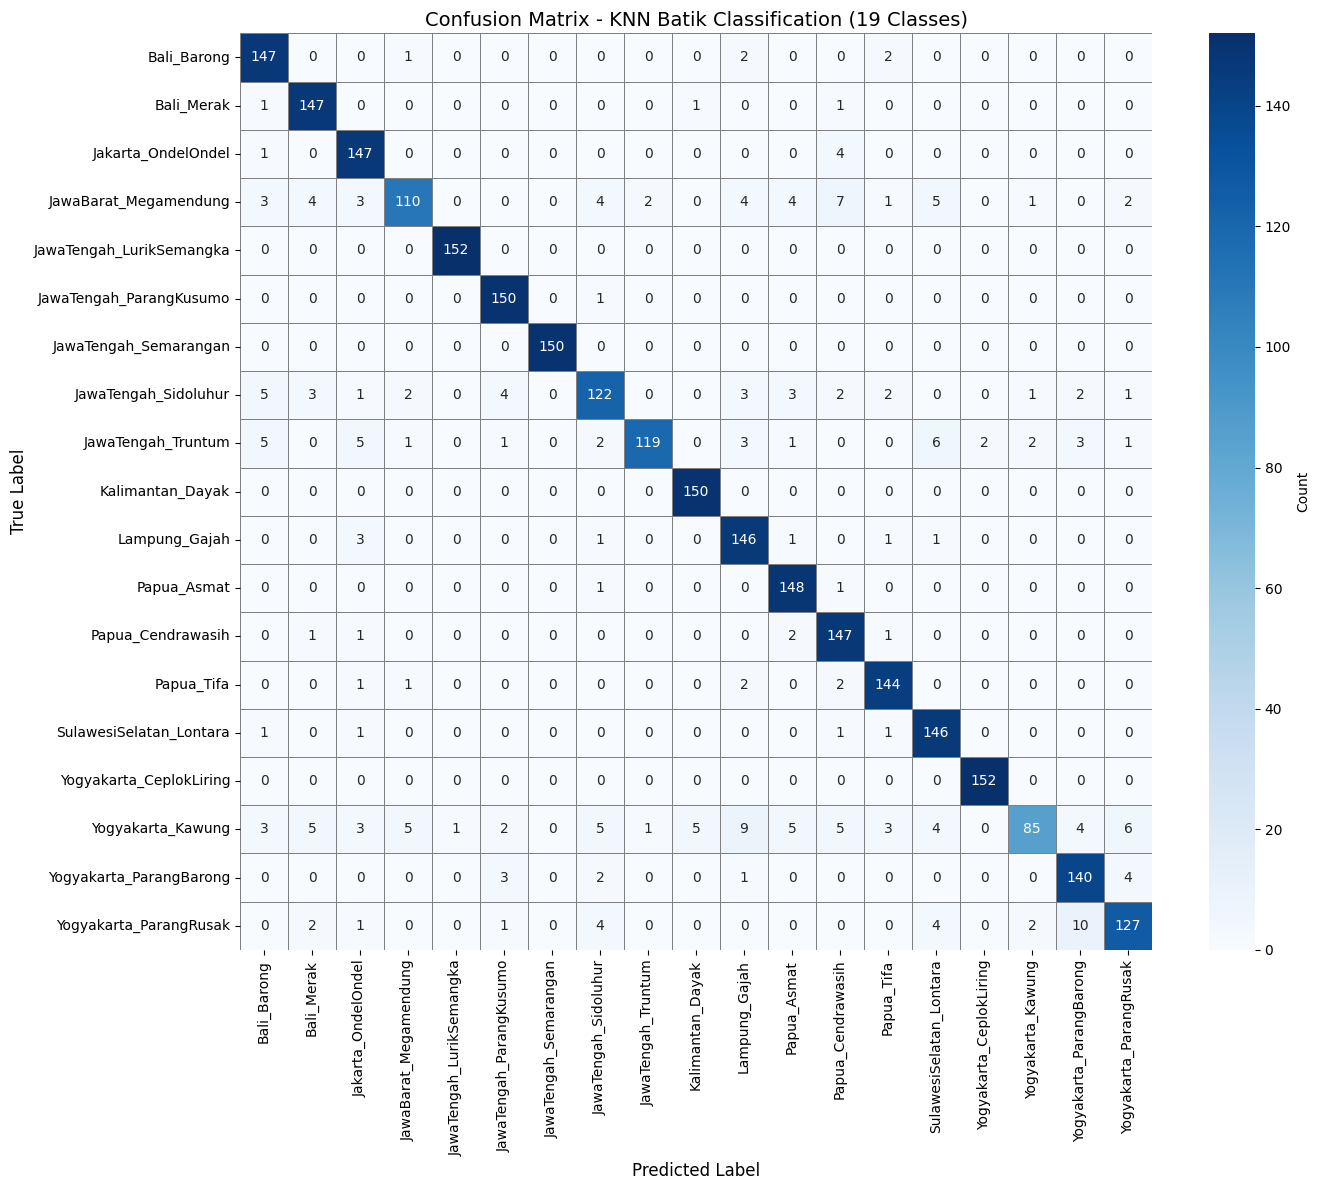

Confusion matrix visualized
Matrix shape: (19, 19)


In [55]:
# Plot confusion matrix
plt.figure(figsize=(14, 12))

classes = sorted(np.unique(y_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='gray')

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - KNN Batik Classification (19 Classes)', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Confusion matrix visualized")
print(f"Matrix shape: {cm.shape}")

### 9.2 Per-Class Performance

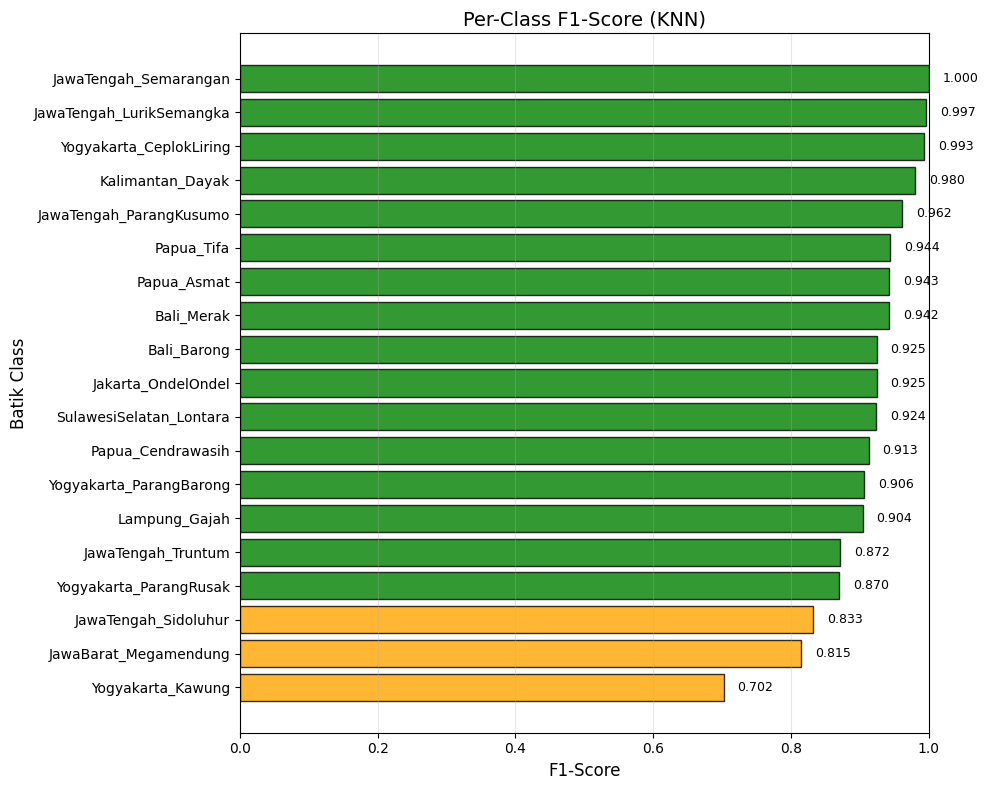

Per-class F1-scores visualized


In [56]:
# Extract per-class F1-scores
f1_scores = []
class_labels = []

for class_name in sorted(report_df.index):
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        f1_scores.append(report_df.loc[class_name, 'f1-score'])
        class_labels.append(class_name)

# Sort by F1-score
sorted_indices = np.argsort(f1_scores)
f1_scores_sorted = np.array(f1_scores)[sorted_indices]
class_labels_sorted = np.array(class_labels)[sorted_indices]

# Plot
plt.figure(figsize=(10, 8))

colors = ['red' if score < 0.7 else 'orange' if score < 0.85 else 'green'
          for score in f1_scores_sorted]

plt.barh(range(len(class_labels_sorted)), f1_scores_sorted,
         color=colors, edgecolor='black', alpha=0.8)

plt.yticks(range(len(class_labels_sorted)), class_labels_sorted)
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Batik Class', fontsize=12)
plt.title('Per-Class F1-Score (KNN)', fontsize=14)
plt.xlim([0, 1])
plt.grid(axis='x', alpha=0.3)

for i, score in enumerate(f1_scores_sorted):
    plt.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Per-class F1-scores visualized")

### 9.3 Model Performance Comparison

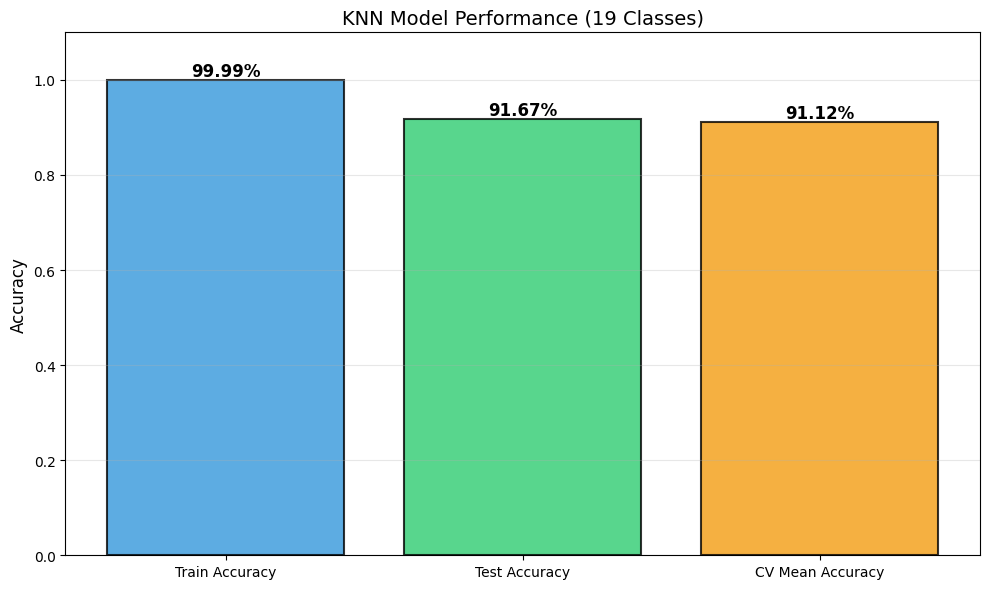

Model performance comparison visualized


In [57]:
# Bar chart of accuracy metrics
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Train Accuracy', 'Test Accuracy', 'CV Mean Accuracy']
values = [train_acc, test_acc, cv_scores.mean()]
colors = ['#3498db', '#2ecc71', '#f39c12']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val*100:.2f}%',
            ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'KNN Model Performance (19 Classes)', fontsize=14)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Model performance comparison visualized")

## 10. Summary

In [58]:
print("="*60)
print("KNN BATIK CLASSIFICATION - FINAL SUMMARY")
print("="*60)
print(f"\nDataset: {DATASET_ROOT}")
print(f"  - Classes: {len(unique_classes)}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"\nFeature Extraction:")
print(f"  - HSV Color Moments: 9 features")
print(f"  - GLCM Texture: 6 features (32 levels, multi-distance)")
print(f"  - LBP Histogram: 26 features")
print(f"  - Total: 41 features")
print(f"  - After PCA (95%): {n_components_kept} features")
print(f"\nModel: K-Nearest Neighbors")
print(f"  - n_neighbors: {KNN_N_NEIGHBORS}")
print(f"  - weights: {KNN_WEIGHTS}")
print(f"  - metric: {KNN_METRIC}")
print(f"\nPerformance:")
print(f"  - Training Accuracy: {train_acc*100:.2f}%")
print(f"  - Test Accuracy: {test_acc*100:.2f}%")
print(f"  - CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
print(f"\nOutput Files:")
print(f"  - Model: {MODEL_NAME}")
print(f"  - Config: {CONFIG_NAME}")
print("="*60)

KNN BATIK CLASSIFICATION - FINAL SUMMARY

Dataset: dataset_20class
  - Classes: 19
  - Training samples: 13337
  - Test samples: 2868

Feature Extraction:
  - HSV Color Moments: 9 features
  - GLCM Texture: 6 features (32 levels, multi-distance)
  - LBP Histogram: 26 features
  - Total: 41 features
  - After PCA (95%): 17 features

Model: K-Nearest Neighbors
  - n_neighbors: 5
  - weights: distance
  - metric: euclidean

Performance:
  - Training Accuracy: 99.99%
  - Test Accuracy: 91.67%
  - CV Accuracy: 91.12% (+/- 0.35%)

Output Files:
  - Model: Batik_KNN_19Class.pkl
  - Config: batik_config_knn_19class.json
